# 7.1 - Data Import & Validation

In [1]:
# Import Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Load the Superstore Dataset

df = pd.read_csv("superstore_clean_utf8.csv")

In [3]:
# Preview the Dataset

df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [4]:
# Check Dataset Dimensions

df.shape

(9994, 21)

In [5]:
# View Column Names

df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit'],
      dtype='object')

In [6]:
# Inspect Data Types

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

In [7]:
# Convert Dates

df["Order Date"] = pd.to_datetime(df["Order Date"])
df["Ship Date"] = pd.to_datetime(df["Ship Date"])

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         9994 non-null   int64         
 1   Order ID       9994 non-null   object        
 2   Order Date     9994 non-null   datetime64[ns]
 3   Ship Date      9994 non-null   datetime64[ns]
 4   Ship Mode      9994 non-null   object        
 5   Customer ID    9994 non-null   object        
 6   Customer Name  9994 non-null   object        
 7   Segment        9994 non-null   object        
 8   Country        9994 non-null   object        
 9   City           9994 non-null   object        
 10  State          9994 non-null   object        
 11  Postal Code    9994 non-null   int64         
 12  Region         9994 non-null   object        
 13  Product ID     9994 non-null   object        
 14  Category       9994 non-null   object        
 15  Sub-Category   9994 n

In [8]:
# Check Missing Values

df.isnull().sum()

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

In [9]:
# Check Duplicate Rows

df.duplicated().sum()

np.int64(0)

In [10]:
# Validate Order Count

df["Order ID"].nunique()

5009

In [11]:
# Validate Customer Count

df["Customer ID"].nunique()

793

In [12]:
# Basic Numerical Summary

df[["Sales", "Quantity", "Discount", "Profit"]].describe()

,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000
mean,229.858001,3.789574,0.156203,28.656896
std,623.245101,2.225110,0.206452,234.260108
min,0.444000,1.000000,0.000000,-6599.978000
25%,17.280000,2.000000,0.000000,1.728750
50%,54.490000,3.000000,0.200000,8.666500
75%,209.940000,5.000000,0.200000,29.364000
max,22638.480000,14.000000,0.800000,8399.976000


# 7.2 - Exploratory Data Analysis

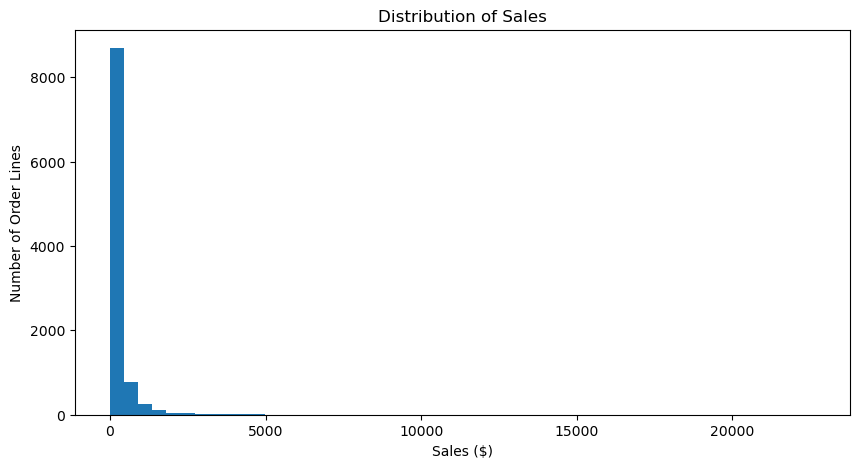

In [13]:
# Sales Distribution

plt.figure(figsize=(10, 5))

plt.hist(df["Sales"], bins=50)

plt.title("Distribution of Sales")
plt.xlabel("Sales ($)")
plt.ylabel("Number of Order Lines")

plt.show()

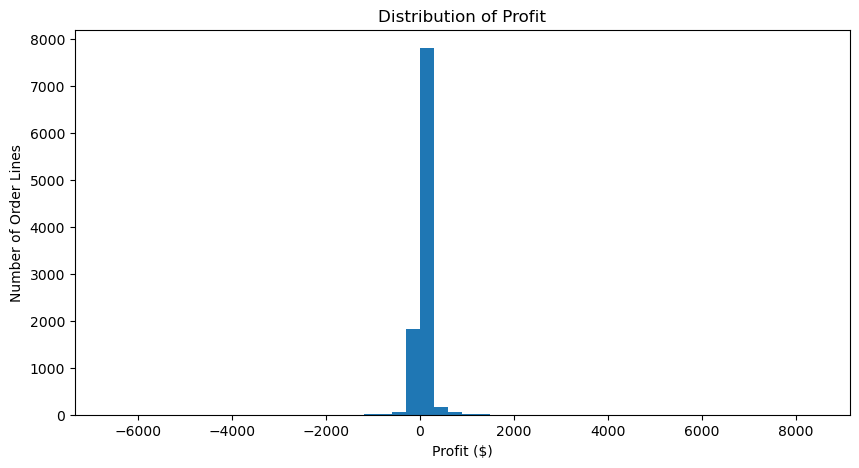

In [14]:
# Profit Distribution

plt.figure(figsize=(10, 5))

plt.hist(df["Profit"], bins=50)

plt.title("Distribution of Profit")
plt.xlabel("Profit ($)")
plt.ylabel("Number of Order Lines")

plt.show()

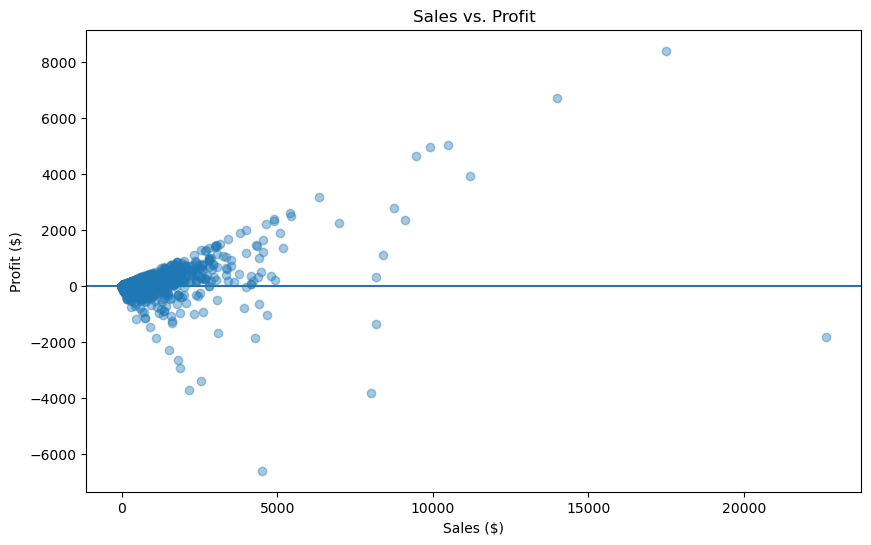

In [15]:
# Sales vs. Profit

plt.figure(figsize=(10, 6))

plt.scatter(df["Sales"], df["Profit"], alpha=0.4)

plt.title("Sales vs. Profit")
plt.xlabel("Sales ($)")
plt.ylabel("Profit ($)")

plt.axhline(0)

plt.show()

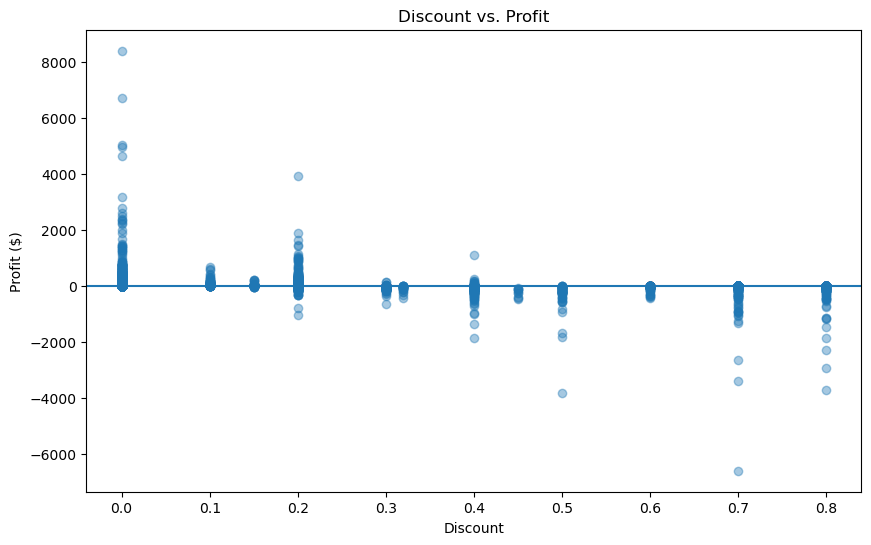

In [16]:
# Discount vs. Profit

plt.figure(figsize=(10, 6))

plt.scatter(df["Discount"], df["Profit"], alpha=0.4)

plt.title("Discount vs. Profit")
plt.xlabel("Discount")
plt.ylabel("Profit ($)")

plt.axhline(0)

plt.show()

In [17]:
# Average Profit by Discount Level

discount_analysis = (
    df.groupby("Discount")
      .agg(
          Average_Profit=("Profit", "mean"),
          Average_Sales=("Sales", "mean"),
          Transactions=("Order ID", "count")
      )
      .reset_index()
)

discount_analysis

,Discount,Average_Profit,Average_Sales,Transactions
0,0.00,66.900292,226.742074,4798
1,0.10,96.055074,578.397351,94
2,0.15,27.288298,529.971567,52
3,0.20,24.702572,209.076940,3657
4,0.30,-45.679636,454.742974,227
5,0.32,-88.560656,536.794770,27
6,0.40,-111.927429,565.134874,206
7,0.45,-226.646464,498.634000,11
8,0.50,-310.703456,892.705152,66
9,0.60,-43.077212,48.150000,138


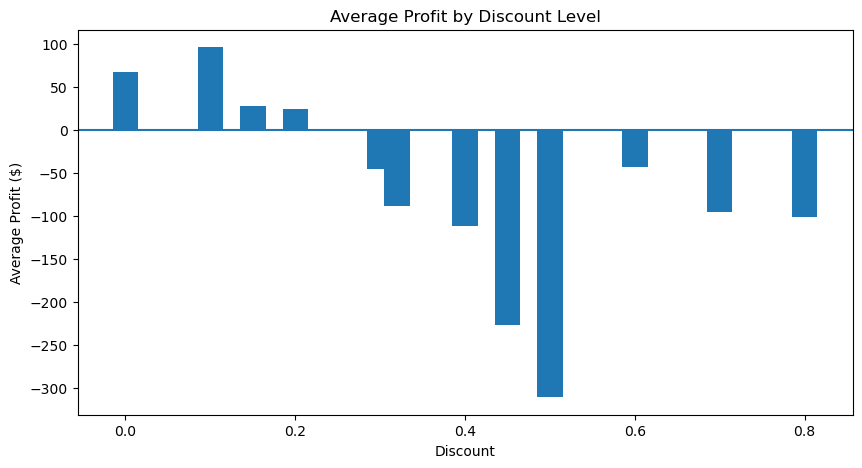

In [18]:
# Visualize Average Profit by Discount 

plt.figure(figsize=(10, 5))

plt.bar(
    discount_analysis["Discount"],
    discount_analysis["Average_Profit"],
    width=0.03
)

plt.title("Average Profit by Discount Level")
plt.xlabel("Discount")
plt.ylabel("Average Profit ($)")

plt.axhline(0)

plt.show()

# 7.3 - Outlier Analysis

In [19]:
# Identify Extreme Sales

df.nlargest(10, "Sales")[
    ["Order ID", "Product Name", "Category", "Sales", "Profit", "Discount"]
]

,Order ID,Product Name,Category,Sales,Profit,Discount
2697,CA-2014-145317,Cisco TelePresence System EX90 Videoconferenci...,Technology,22638.480,-1811.0784,0.5
6826,CA-2016-118689,Canon imageCLASS 2200 Advanced Copier,Technology,17499.950,8399.9760,0.0
8153,CA-2017-140151,Canon imageCLASS 2200 Advanced Copier,Technology,13999.960,6719.9808,0.0
2623,CA-2017-127180,Canon imageCLASS 2200 Advanced Copier,Technology,11199.968,3919.9888,0.2
4190,CA-2017-166709,Canon imageCLASS 2200 Advanced Copier,Technology,10499.970,5039.9856,0.0
9039,CA-2016-117121,GBC Ibimaster 500 Manual ProClick Binding System,Office Supplies,9892.740,4946.3700,0.0
4098,CA-2014-116904,Ibico EPK-21 Electric Binding System,Office Supplies,9449.950,4630.4755,0.0
4277,US-2016-107440,"3D Systems Cube Printer, 2nd Generation, Magenta",Technology,9099.930,2365.9818,0.0
8488,CA-2016-158841,HP Designjet T520 Inkjet Large Format Printer ...,Technology,8749.950,2799.9840,0.0
6425,CA-2016-143714,Canon imageCLASS 2200 Advanced Copier,Technology,8399.976,1119.9968,0.4


In [20]:
# Largest Profits

df.nlargest(10, "Profit")[
    ["Order ID", "Product Name", "Category", "Sales", "Profit", "Discount"]
]

,Order ID,Product Name,Category,Sales,Profit,Discount
6826,CA-2016-118689,Canon imageCLASS 2200 Advanced Copier,Technology,17499.950,8399.9760,0.0
8153,CA-2017-140151,Canon imageCLASS 2200 Advanced Copier,Technology,13999.960,6719.9808,0.0
4190,CA-2017-166709,Canon imageCLASS 2200 Advanced Copier,Technology,10499.970,5039.9856,0.0
9039,CA-2016-117121,GBC Ibimaster 500 Manual ProClick Binding System,Office Supplies,9892.740,4946.3700,0.0
4098,CA-2014-116904,Ibico EPK-21 Electric Binding System,Office Supplies,9449.950,4630.4755,0.0
2623,CA-2017-127180,Canon imageCLASS 2200 Advanced Copier,Technology,11199.968,3919.9888,0.2
509,CA-2015-145352,Fellowes PB500 Electric Punch Plastic Comb Bin...,Office Supplies,6354.950,3177.4750,0.0
8488,CA-2016-158841,HP Designjet T520 Inkjet Large Format Printer ...,Technology,8749.950,2799.9840,0.0
7666,US-2016-140158,Hewlett Packard LaserJet 3310 Copier,Technology,5399.910,2591.9568,0.0
6520,CA-2017-138289,GBC DocuBind P400 Electric Binding System,Office Supplies,5443.960,2504.2216,0.0


In [21]:
# Largest Losses

df.nsmallest(10, "Profit")[
    ["Order ID", "Product Name", "Category", "Sales", "Profit", "Discount"]
]

,Order ID,Product Name,Category,Sales,Profit,Discount
7772,CA-2016-108196,Cubify CubeX 3D Printer Double Head Print,Technology,4499.985,-6599.9780,0.7
683,US-2017-168116,Cubify CubeX 3D Printer Triple Head Print,Technology,7999.980,-3839.9904,0.5
9774,CA-2014-169019,GBC DocuBind P400 Electric Binding System,Office Supplies,2177.584,-3701.8928,0.8
3011,CA-2017-134845,Lexmark MX611dhe Monochrome Laser Printer,Technology,2549.985,-3399.9800,0.7
4991,US-2017-122714,Ibico EPK-21 Electric Binding System,Office Supplies,1889.990,-2929.4845,0.8
3151,CA-2015-147830,Cubify CubeX 3D Printer Double Head Print,Technology,1799.994,-2639.9912,0.7
5310,CA-2017-131254,Fellowes PB500 Electric Punch Plastic Comb Bin...,Office Supplies,1525.188,-2287.7820,0.8
9639,CA-2015-116638,Chromcraft Bull-Nose Wood Oval Conference Tabl...,Furniture,4297.644,-1862.3124,0.4
1199,CA-2016-130946,GBC DocuBind P400 Electric Binding System,Office Supplies,1088.792,-1850.9464,0.8
2697,CA-2014-145317,Cisco TelePresence System EX90 Videoconferenci...,Technology,22638.480,-1811.0784,0.5


In [22]:
# Quantify Loss-making Transactions

loss_rate = (df["Profit"] < 0).mean() * 100

print(f"Percentage of loss-making order lines: {loss_rate:.2f}%")

Percentage of loss-making order lines: 18.72%


# 7.4 - Correlation & Statistical Analysis

In [23]:
# Correlation Matrix

numeric_cols = df[["Sales", "Quantity", "Discount", "Profit"]]

correlation_matrix = numeric_cols.corr()

correlation_matrix

,Sales,Quantity,Discount,Profit
Sales,1.000000,0.200795,-0.028190,0.479064
Quantity,0.200795,1.000000,0.008623,0.066253
Discount,-0.028190,0.008623,1.000000,-0.219487
Profit,0.479064,0.066253,-0.219487,1.000000


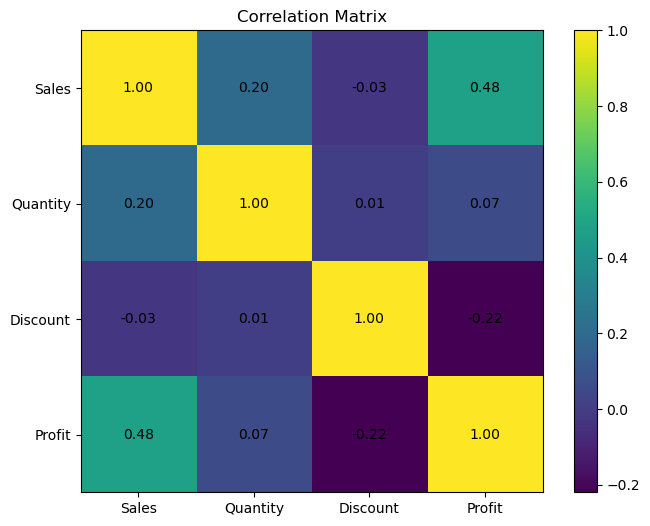

In [24]:
# Visualize the Correlation Matrix

fig, ax = plt.subplots(figsize=(8, 6))

im = ax.imshow(correlation_matrix)

ax.set_xticks(range(len(correlation_matrix.columns)))
ax.set_yticks(range(len(correlation_matrix.columns)))

ax.set_xticklabels(correlation_matrix.columns)
ax.set_yticklabels(correlation_matrix.columns)

for i in range(len(correlation_matrix.columns)):
    for j in range(len(correlation_matrix.columns)):
        ax.text(
            j,
            i,
            f"{correlation_matrix.iloc[i, j]:.2f}",
            ha="center",
            va="center"
        )

plt.title("Correlation Matrix")
plt.colorbar(im)
plt.show()

# 7.5 - Statistical Testing

In [25]:
# Import Statistical Functions

from scipy import stats

In [26]:
# Create Two Discount Groups

low_discount_profit = df.loc[
    df["Discount"] <= 0.20,
    "Profit"
]

high_discount_profit = df.loc[
    df["Discount"] > 0.20,
    "Profit"
]

print("Low-discount observations:", len(low_discount_profit))
print("High-discount observations:", len(high_discount_profit))

Low-discount observations: 8601
High-discount observations: 1393


In [27]:
# Compare Average Profitability

print(
    f"Low-discount average profit: "
    f"${low_discount_profit.mean():.2f}"
)

print(
    f"High-discount average profit: "
    f"${high_discount_profit.mean():.2f}"
)

Low-discount average profit: $49.04
High-discount average profit: $-97.18


In [28]:
# Welch's T-test

t_stat, p_value = stats.ttest_ind(
    low_discount_profit,
    high_discount_profit,
    equal_var=False
)

print(f"T-statistic: {t_stat:.3f}")
print(f"P-value: {p_value:.6f}")

T-statistic: 16.141
P-value: 0.000000


In [29]:
# Calculate the Actual Difference

low_mean = low_discount_profit.mean()
high_mean = high_discount_profit.mean()

difference = low_mean - high_mean

print(f"Low-discount average profit: ${low_mean:.2f}")
print(f"High-discount average profit: ${high_mean:.2f}")
print(f"Difference: ${difference:.2f}")

Low-discount average profit: $49.04
High-discount average profit: $-97.18
Difference: $146.22


# 7.6 - Category Profitability Test

In [30]:
# Create Category Groups

furniture_profit = df.loc[
    df["Category"] == "Furniture",
    "Profit"
]

office_profit = df.loc[
    df["Category"] == "Office Supplies",
    "Profit"
]

technology_profit = df.loc[
    df["Category"] == "Technology",
    "Profit"
]

In [31]:
# Compare Category Averages

category_summary = (
    df.groupby("Category")["Profit"]
      .agg(["count", "mean", "median", "std"])
      .round(2)
)

category_summary

,count,mean,median,std
Category,,,,
Furniture,2121,8.70,7.77,136.05
Office Supplies,6026,20.33,6.88,164.89
Technology,1847,78.75,25.02,428.82


In [32]:
# One-way ANOVA

f_stat, p_value = stats.f_oneway(
    furniture_profit,
    office_profit,
    technology_profit
)

print(f"F-statistic: {f_stat:.3f}")
print(f"P-value: {p_value:.6f}")

F-statistic: 54.311
P-value: 0.000000


# 7.7 Shipping Time Analysis

In [33]:
# Calculate Shipping Time

df["Shipping Days"] = (
    df["Ship Date"] - df["Order Date"]
).dt.days

df[[
    "Order Date",
    "Ship Date",
    "Ship Mode",
    "Shipping Days"
]].head()

,Order Date,Ship Date,Ship Mode,Shipping Days
0,2016-11-08,2016-11-11,Second Class,3
1,2016-11-08,2016-11-11,Second Class,3
2,2016-06-12,2016-06-16,Second Class,4
3,2015-10-11,2015-10-18,Standard Class,7
4,2015-10-11,2015-10-18,Standard Class,7


In [34]:
# Shipping Performance by Mode

shipping_summary = (
    df.groupby("Ship Mode")["Shipping Days"]
      .agg(["count", "mean", "median", "min", "max"])
      .round(2)
      .sort_values("mean")
)

shipping_summary

,count,mean,median,min,max
Ship Mode,,,,,
Same Day,543,0.04,0.0,0,1
First Class,1538,2.18,2.0,1,4
Second Class,1945,3.24,3.0,1,5
Standard Class,5968,5.01,5.0,3,7


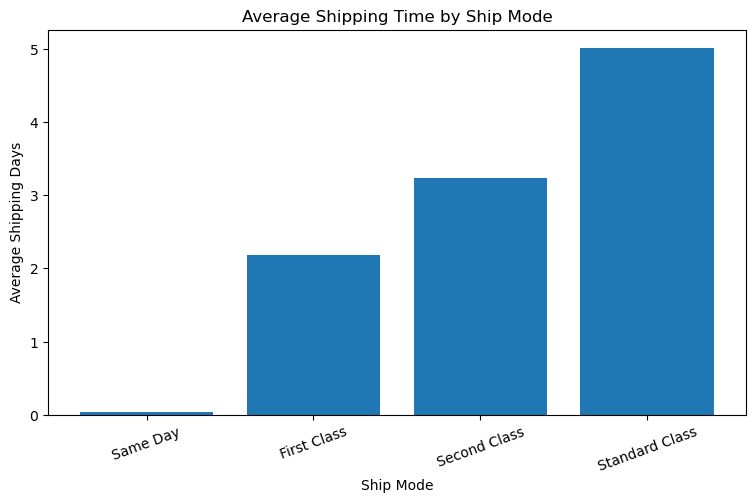

In [35]:
# Visualize Average Shipping Time

avg_shipping = (
    df.groupby("Ship Mode")["Shipping Days"]
      .mean()
      .sort_values()
)

plt.figure(figsize=(9, 5))

plt.bar(
    avg_shipping.index,
    avg_shipping.values
)

plt.title("Average Shipping Time by Ship Mode")
plt.xlabel("Ship Mode")
plt.ylabel("Average Shipping Days")

plt.xticks(rotation=20)

plt.show()

# 7.8 - Final Findings & Business Interpretation

In [36]:
# Core Python Findings

loss_rate = (df["Profit"] < 0).mean() * 100

discount_profit_corr = df["Discount"].corr(df["Profit"])

low_mean = low_discount_profit.mean()
high_mean = high_discount_profit.mean()

avg_shipping = (
    df.groupby("Ship Mode")["Shipping Days"]
      .mean()
      .sort_values()
)

print("KEY ANALYTICAL FINDINGS")
print("-" * 50)

print(f"1. Loss-making order lines: {loss_rate:.2f}%")

print(
    f"2. Discount-profit correlation: "
    f"{discount_profit_corr:.3f}"
)

print(
    f"3. Average profit on low-discount transactions: "
    f"${low_mean:.2f}"
)

print(
    f"4. Average profit on high-discount transactions: "
    f"${high_mean:.2f}"
)

print(
    f"5. Difference in average profit: "
    f"${low_mean - high_mean:.2f}"
)

print("\nAverage Shipping Days:")
print(avg_shipping.round(2))

KEY ANALYTICAL FINDINGS
--------------------------------------------------
1. Loss-making order lines: 18.72%
2. Discount-profit correlation: -0.219
3. Average profit on low-discount transactions: $49.04
4. Average profit on high-discount transactions: $-97.18
5. Difference in average profit: $146.22

Average Shipping Days:
Ship Mode
Same Day          0.04
First Class       2.18
Second Class      3.24
Standard Class    5.01
Name: Shipping Days, dtype: float64


In [37]:
# Category Summary 

category_findings = (
    df.groupby("Category")
      .agg(
          Revenue=("Sales", "sum"),
          Profit=("Profit", "sum"),
          Average_Profit=("Profit", "mean"),
          Average_Discount=("Discount", "mean")
      )
)

category_findings["Profit_Margin_Pct"] = (
    category_findings["Profit"]
    / category_findings["Revenue"]
    * 100
)

category_findings.round(2)

,Revenue,Profit,Average_Profit,Average_Discount,Profit_Margin_Pct
Category,,,,,
Furniture,741999.80,18451.27,8.70,0.17,2.49
Office Supplies,719047.03,122490.80,20.33,0.16,17.04
Technology,836154.03,145454.95,78.75,0.13,17.40


In [38]:
# Statistical Findings

print("STATISTICAL TEST RESULTS")
print("-" * 50)

t_stat, discount_p = stats.ttest_ind(
    low_discount_profit,
    high_discount_profit,
    equal_var=False
)

f_stat, category_p = stats.f_oneway(
    furniture_profit,
    office_profit,
    technology_profit
)

print("Discount Profitability Test")
print(f"T-statistic: {t_stat:.3f}")
print(f"P-value: {discount_p:.6f}")

print()

print("Category Profitability ANOVA")
print(f"F-statistic: {f_stat:.3f}")
print(f"P-value: {category_p:.6f}")

STATISTICAL TEST RESULTS
--------------------------------------------------
Discount Profitability Test
T-statistic: 16.141
P-value: 0.000000

Category Profitability ANOVA
F-statistic: 54.311
P-value: 0.000000


In [39]:
# Generate a Findings Table

findings = pd.DataFrame({
    "Metric": [
        "Loss-Making Order Lines",
        "Discount-Profit Correlation",
        "Low-Discount Average Profit",
        "High-Discount Average Profit",
        "Profit Difference"
    ],
    "Value": [
        f"{loss_rate:.2f}%",
        f"{discount_profit_corr:.3f}",
        f"${low_mean:.2f}",
        f"${high_mean:.2f}",
        f"${low_mean - high_mean:.2f}"
    ]
})

findings

,Metric,Value
0,Loss-Making Order Lines,18.72%
1,Discount-Profit Correlation,-0.219
2,Low-Discount Average Profit,$49.04
3,High-Discount Average Profit,$-97.18
4,Profit Difference,$146.22


In [40]:
# Export Findings

findings.to_csv(
    "python_key_findings.csv",
    index=False
)

## Python Analysis Summary

Python was used to supplement the SQL analysis with data-quality validation,
exploratory visualization, outlier detection, feature engineering, correlation
analysis, and statistical hypothesis testing.

The analysis focused particularly on the relationship between discounting and
profitability, differences in profitability across product categories, and
shipping performance across fulfillment methods.

These findings will be combined with the SQL analysis to develop the final
interactive business intelligence dashboard and executive recommendations.